# Full Prior Module Test Notebook

This notebook is a **complete test harness** for the `simplified_prior` data generation module.

It validates:
- API surface and available options
- ID mapper round-trips
- config normalization and constraints
- Cox/AFT baseline samplers
- event-time samplers
- censoring samplers
- full end-to-end `(X, y, T, C, observed_T, delta)` generation invariants

If any core behavior regresses, a test cell should fail with a clear assertion.


In [11]:
from __future__ import annotations

from pathlib import Path
import sys
import math
from collections import Counter

import numpy as np
import pandas as pd
try:
    import matplotlib.pyplot as plt
    HAS_MATPLOTLIB = True
except Exception:
    plt = None
    HAS_MATPLOTLIB = False
try:
    from IPython.display import display
except Exception:
    def display(x):
        print(x)

# Resolve project root robustly.
candidates = [Path.cwd(), Path.cwd().parent, Path.cwd().parent.parent]
PROJECT_ROOT = None
for c in candidates:
    if (c / 'simplified_prior').exists():
        PROJECT_ROOT = c
        break
if PROJECT_ROOT is None:
    raise RuntimeError('Could not locate project root containing simplified_prior/.')
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from simplified_prior import (
    __all__ as prior_all,
    ADMINISTRATIVE_JITTER_MODES,
    AFT_FAMILIES,
    AFT_TIERS,
    CENSORING_MODES,
    COX_BASELINE_FAMILIES,
    COX_BASELINE_TIERS,
    GENERATION_MODES,
    LOG_LOCATION_CENSORING_FAMILIES,
    SAMPLING_MODES,
    TTE_MODELS,
    SimplifiedPriorConfig,
    available_aft_families,
    available_aft_tiers,
    available_censoring_modes,
    available_cox_baseline_families,
    available_cox_baseline_tiers,
    available_difficulties,
    available_log_location_censoring_families,
    available_nonlinearities,
    available_tte_models,
    sample_aft_spec,
    sample_censoring_mode,
    sample_cox_baseline,
    sample_event_times_aft,
    sample_event_times_cox,
    sample_log_location_censoring_family,
    sample_right_censoring,
    sample_tte_model,
    split_dataset,
    tte_model_to_id,
    tte_model_from_id,
    cox_tier_to_id,
    cox_tier_from_id,
    cox_baseline_family_to_id,
    cox_baseline_family_from_id,
    aft_tier_to_id,
    aft_tier_from_id,
    aft_family_to_id,
    aft_family_from_id,
    censoring_mode_to_id,
    censoring_mode_from_id,
    log_location_censoring_family_to_id,
    log_location_censoring_family_from_id,
    y_to_linear_predictor,
    generate_simplified_prior_data,
)

np.random.seed(0)
if HAS_MATPLOTLIB:
    try:
        plt.style.use('seaborn-v0_8-whitegrid')
    except Exception:
        plt.style.use('default')

print('PROJECT_ROOT =', PROJECT_ROOT)
print('exported symbols =', len(prior_all))


PROJECT_ROOT = /Users/qltian/Library/CloudStorage/GoogleDrive-qltian2021@gmail.com/Other computers/My Laptop/Documents/Research/ai/surv_icl
exported symbols = 62


## 1) API Inventory and Basic Availability Checks

In [12]:
api_inventory = {
    'GENERATION_MODES': tuple(GENERATION_MODES),
    'SAMPLING_MODES': tuple(SAMPLING_MODES),
    'TTE_MODELS': tuple(TTE_MODELS),
    'COX_BASELINE_TIERS': tuple(COX_BASELINE_TIERS),
    'COX_BASELINE_FAMILIES': tuple(COX_BASELINE_FAMILIES),
    'AFT_TIERS': tuple(AFT_TIERS),
    'AFT_FAMILIES': tuple(AFT_FAMILIES),
    'CENSORING_MODES': tuple(CENSORING_MODES),
    'LOG_LOCATION_CENSORING_FAMILIES': tuple(LOG_LOCATION_CENSORING_FAMILIES),
    'ADMINISTRATIVE_JITTER_MODES': tuple(ADMINISTRATIVE_JITTER_MODES),
    'available_tte_models': tuple(available_tte_models()),
    'available_cox_baseline_tiers': tuple(available_cox_baseline_tiers()),
    'available_cox_baseline_families': tuple(available_cox_baseline_families()),
    'available_aft_tiers': tuple(available_aft_tiers()),
    'available_aft_families': tuple(available_aft_families()),
    'available_censoring_modes': tuple(available_censoring_modes()),
    'available_log_location_censoring_families': tuple(available_log_location_censoring_families()),
}

df_inventory = pd.DataFrame([
    {'name': k, 'values': ', '.join(v), 'count': len(v)} for k, v in api_inventory.items()
]).sort_values('name').reset_index(drop=True)

display(df_inventory)

# Basic sanity asserts.
assert len(available_nonlinearities()) > 0
assert len(available_difficulties()) > 0
assert set(available_tte_models()) == set(TTE_MODELS)
assert set(available_censoring_modes()) == set(CENSORING_MODES)
print('API inventory checks passed.')


,name,values,count
0,ADMINISTRATIVE_JITTER_MODES,"lognormal, uniform",2
1,AFT_FAMILIES,"normal, logistic, gumbel, student_t, generaliz...",8
2,AFT_TIERS,"tier1, tier2, tier3, tier4",4
3,CENSORING_MODES,"log_location, administrative",2
4,COX_BASELINE_FAMILIES,"exponential, weibull, gompertz, piecewise, mix...",5
5,COX_BASELINE_TIERS,"tier1, tier2, tier3, tier4",4
6,GENERATION_MODES,"causal, head, roots",3
7,LOG_LOCATION_CENSORING_FAMILIES,"normal, logistic, student_t",3
8,SAMPLING_MODES,"normal, uniform",2
9,TTE_MODELS,"cox, aft",2


API inventory checks passed.


## 2) ID Mapper Round-Trip Tests

In [13]:
def roundtrip(values, to_id, from_id, name):
    rows = []
    for v in values:
        i = to_id(v)
        back = from_id(i)
        rows.append({'name': name, 'value': v, 'id': i, 'back': back, 'ok': v == back})
    out = pd.DataFrame(rows)
    assert out['ok'].all(), f'{name} roundtrip failed'
    return out

rt = pd.concat([
    roundtrip(TTE_MODELS, tte_model_to_id, tte_model_from_id, 'tte_model'),
    roundtrip(COX_BASELINE_TIERS, cox_tier_to_id, cox_tier_from_id, 'cox_tier'),
    roundtrip(COX_BASELINE_FAMILIES, cox_baseline_family_to_id, cox_baseline_family_from_id, 'cox_family'),
    roundtrip(AFT_TIERS, aft_tier_to_id, aft_tier_from_id, 'aft_tier'),
    roundtrip(AFT_FAMILIES, aft_family_to_id, aft_family_from_id, 'aft_family'),
    roundtrip(CENSORING_MODES, censoring_mode_to_id, censoring_mode_from_id, 'censoring_mode'),
    roundtrip(LOG_LOCATION_CENSORING_FAMILIES, log_location_censoring_family_to_id, log_location_censoring_family_from_id, 'log_location_family'),
], ignore_index=True)

display(rt)
print('Round-trip mapper checks passed.')


,name,value,id,back,ok
0,tte_model,cox,0,cox,True
1,tte_model,aft,1,aft,True
2,cox_tier,tier1,0,tier1,True
3,cox_tier,tier2,1,tier2,True
4,cox_tier,tier3,2,tier3,True
5,cox_tier,tier4,3,tier4,True
6,cox_family,exponential,0,exponential,True
7,cox_family,weibull,1,weibull,True
8,cox_family,gompertz,2,gompertz,True
9,cox_family,piecewise,3,piecewise,True


Round-trip mapper checks passed.


## 3) Config Behavior and Constraints

In [14]:
# nu is fixed to 1 even if user provides a different value.
cfg_nu = SimplifiedPriorConfig(nu=7.5)
assert cfg_nu.nu == 1.0

# generation_mode auto resolution.
cfg_auto_head = SimplifiedPriorConfig(generation_mode='auto', is_causal=False, noncausal_feature_source='head')
assert cfg_auto_head.generation_mode == 'head'

cfg_auto_roots = SimplifiedPriorConfig(
    generation_mode='auto',
    is_causal=False,
    noncausal_feature_source='roots',
    num_features=8,
    num_causes=8,
)
assert cfg_auto_roots.generation_mode == 'roots'

cfg_auto_causal = SimplifiedPriorConfig(generation_mode='auto', is_causal=True)
assert cfg_auto_causal.generation_mode == 'causal'

# roots mode must satisfy num_causes == num_features.
raised = False
try:
    SimplifiedPriorConfig(generation_mode='roots', num_features=8, num_causes=7)
except ValueError:
    raised = True
assert raised, 'Expected ValueError for roots mode dimension mismatch.'

# y_to_linear_predictor should return y directly (nu fixed behavior).
y = np.array([-2.0, 0.0, 3.0], dtype=np.float32)
eta = y_to_linear_predictor(
    __import__('torch').tensor(y),
    nu=999.0,
).numpy()
assert np.allclose(eta, y)

print('Config behavior checks passed.')


Config behavior checks passed.


## 4) Direct Sampler Coverage (TTE / Cox / AFT / Censoring)

In [15]:
rng = np.random.default_rng(123)

# TTE model sampler.
cfg_tte_auto = SimplifiedPriorConfig(tte_model='auto', p_cox=0.7)
models = [sample_tte_model(cfg_tte_auto, rng=rng) for _ in range(400)]
p_cox_emp = np.mean(np.array(models) == 'cox')
assert 0.58 <= p_cox_emp <= 0.82

# Censoring mode sampler.
cfg_c_auto = SimplifiedPriorConfig(censoring_mode='auto', p_administrative_censoring=0.65)
cmodes = [sample_censoring_mode(cfg_c_auto, rng=rng) for _ in range(400)]
p_admin_emp = np.mean(np.array(cmodes) == 'administrative')
assert 0.53 <= p_admin_emp <= 0.78

# Log-location family sampler.
cfg_log_family = SimplifiedPriorConfig(censoring_log_location_family='auto')
lfams = [sample_log_location_censoring_family(cfg_log_family, rng=rng) for _ in range(400)]
assert set(lfams).issubset(set(LOG_LOCATION_CENSORING_FAMILIES))

# Cox baseline sampler by tier.
cox_rows = []
for tier in COX_BASELINE_TIERS:
    cfg = SimplifiedPriorConfig(cox_tier=tier)
    for _ in range(120):
        s = sample_cox_baseline(cfg, rng=rng)
        cox_rows.append({'tier': tier, 'family': s['family'], 'm': int(s.get('mixture_num_components', 0))})
cox_df = pd.DataFrame(cox_rows)

allowed_cox = {
    'tier1': {'exponential', 'weibull', 'gompertz'},
    'tier2': {'exponential', 'weibull', 'gompertz', 'piecewise'},
    'tier3': {'weibull', 'gompertz', 'piecewise'},
    'tier4': {'mixture'},
}
for tier, g in cox_df.groupby('tier'):
    got = set(g['family'])
    assert got.issubset(allowed_cox[tier]), (tier, got)
    if tier == 'tier4':
        assert (g['m'] >= 2).all()

# AFT sampler by tier.
aft_rows = []
for tier in AFT_TIERS:
    cfg = SimplifiedPriorConfig(aft_tier=tier)
    for _ in range(120):
        s = sample_aft_spec(cfg, rng=rng)
        aft_rows.append({'tier': tier, 'family': s['family'], 'm': int(s.get('mixture_num_components', 0))})
aft_df = pd.DataFrame(aft_rows)

allowed_aft = {
    'tier1': {'normal', 'logistic', 'gumbel'},
    'tier2': {'student_t', 'generalized_gamma', 'gev'},
    'tier3': {'skew_normal', 'student_t', 'generalized_gamma', 'gev'},
    'tier4': {'mixture'},
}
for tier, g in aft_df.groupby('tier'):
    got = set(g['family'])
    assert got.issubset(allowed_aft[tier]), (tier, got)
    if tier == 'tier4':
        assert (g['m'] >= 2).all()

print('Sampler coverage checks passed.')
display(cox_df.groupby(['tier', 'family']).size().rename('count').reset_index())
display(aft_df.groupby(['tier', 'family']).size().rename('count').reset_index())


Sampler coverage checks passed.


,tier,family,count
0,tier1,exponential,65
1,tier1,gompertz,21
2,tier1,weibull,34
3,tier2,exponential,24
4,tier2,gompertz,27
5,tier2,piecewise,25
6,tier2,weibull,44
7,tier3,gompertz,17
8,tier3,piecewise,67
9,tier3,weibull,36


,tier,family,count
0,tier1,gumbel,32
1,tier1,logistic,40
2,tier1,normal,48
3,tier2,generalized_gamma,46
4,tier2,gev,30
5,tier2,student_t,44
6,tier3,generalized_gamma,22
7,tier3,gev,13
8,tier3,skew_normal,46
9,tier3,student_t,39


## 5) Event-Time Sampler Tests (Cox and AFT families)

In [16]:
rng = np.random.default_rng(2026)
eta = rng.normal(0, 1, size=500)

cox_specs = [
    {'family': 'exponential'},
    {'family': 'weibull', 'weibull_k': 1.4},
    {'family': 'gompertz', 'gompertz_alpha': 0.15},
    {
        'family': 'piecewise',
        'piecewise_breakpoints': np.array([0.7, 1.8, 3.0], dtype=np.float32),
        'piecewise_hazards': np.array([0.8, 1.2, 0.9, 0.6], dtype=np.float32),
    },
    {
        'family': 'mixture',
        'mixture_num_components': 3,
        'mixture_weights': np.array([0.4, 0.35, 0.25], dtype=np.float32),
        'mixture_component_family_ids': np.array([
            cox_baseline_family_to_id('exponential'),
            cox_baseline_family_to_id('weibull'),
            cox_baseline_family_to_id('gompertz'),
        ], dtype=np.int64),
        'mixture_component_weibull_k': np.array([np.nan, 1.6, np.nan], dtype=np.float32),
        'mixture_component_gompertz_alpha': np.array([np.nan, np.nan, 0.1], dtype=np.float32),
    },
]

cox_stat = []
for s in cox_specs:
    t, log_t = sample_event_times_cox(eta=eta, cox_spec=s, rng=rng)
    assert np.isfinite(t).all() and np.isfinite(log_t).all()
    assert (t > 0).all()
    cox_stat.append({'family': s['family'], 't_min': float(np.min(t)), 't_max': float(np.max(t)), 'log_t_std': float(np.std(log_t))})

aft_specs = [
    {'family': 'normal', 'sigma': 1.0},
    {'family': 'logistic', 'sigma': 1.0},
    {'family': 'gumbel', 'sigma': 1.0},
    {'family': 'student_t', 'sigma': 1.0, 'student_df': 8.0},
    {'family': 'generalized_gamma', 'gg_k': 1.2, 'gg_p': 1.1},
    {'family': 'gev', 'gev_xi': 0.1},
    {'family': 'skew_normal', 'sigma': 1.0, 'skew_alpha': 2.0},
    {
        'family': 'mixture',
        'mixture_num_components': 3,
        'mixture_weights': np.array([0.45, 0.35, 0.20], dtype=np.float32),
        'mixture_component_family_ids': np.array([
            aft_family_to_id('normal'),
            aft_family_to_id('student_t'),
            aft_family_to_id('skew_normal'),
        ], dtype=np.int64),
        'mixture_component_sigma': np.array([1.0, 1.1, 0.9], dtype=np.float32),
        'mixture_component_student_df': np.array([np.nan, 10.0, np.nan], dtype=np.float32),
        'mixture_component_skew_alpha': np.array([np.nan, np.nan, 3.0], dtype=np.float32),
    },
]

aft_stat = []
for s in aft_specs:
    t, log_t = sample_event_times_aft(eta=eta, aft_spec=s, cfg=None, rng=rng)
    assert np.isfinite(t).all() and np.isfinite(log_t).all()
    assert (t > 0).all()
    aft_stat.append({'family': s['family'], 't_min': float(np.min(t)), 't_max': float(np.max(t)), 'log_t_std': float(np.std(log_t))})

display(pd.DataFrame(cox_stat))
display(pd.DataFrame(aft_stat))
print('Event-time sampler checks passed.')


,family,t_min,t_max,log_t_std
0,exponential,0.000648,27.917219,1.707739
1,weibull,0.009834,16.188154,1.114426
2,gompertz,0.000062,14.870016,1.661164
3,piecewise,0.000155,83.394760,1.619364
4,mixture,0.000190,58.957962,1.493990


,family,t_min,t_max,log_t_std
0,normal,0.020681,102.704796,1.435774
1,logistic,0.001118,1060.566406,1.895900
2,gumbel,0.025775,1357.347412,1.648171
3,student_t,0.006433,58.674362,1.542085
4,generalized_gamma,0.000527,92.315041,1.570680
5,gev,0.027901,136776.359375,1.897688
6,skew_normal,0.019191,53.255970,1.261771
7,mixture,0.001354,160.895660,1.457551


Event-time sampler checks passed.


## 6) Censoring Sampler Tests

In [17]:
rng = np.random.default_rng(99)
base_T = np.exp(rng.normal(loc=0.0, scale=1.0, size=600))

cfg_admin = SimplifiedPriorConfig(
    censoring_mode='administrative',
    censoring_admin_target_rate_min=0.30,
    censoring_admin_target_rate_max=0.30,
    seed=99,
)

cfg_logloc = SimplifiedPriorConfig(
    censoring_mode='log_location',
    censoring_log_location_family='student_t',
    censoring_log_location_shift_min=-0.4,
    censoring_log_location_shift_max=-0.4,
    seed=99,
)

out_admin = sample_right_censoring(base_T, cfg_admin, rng=rng)
out_logloc = sample_right_censoring(base_T, cfg_logloc, rng=rng)

def validate_censoring_out(o):
    T = base_T
    C = np.asarray(o['C'])
    O = np.asarray(o['observed_T'])
    D = np.asarray(o['delta'])
    assert np.isfinite(C).all() and np.isfinite(O).all()
    assert (C > 0).all() and (O > 0).all()
    assert np.allclose(O, np.minimum(T, C))
    assert np.all((D == 0.0) | (D == 1.0))
    assert abs(float(np.mean(D)) - float(o['event_rate'])) < 1e-6
    assert abs(1.0 - float(np.mean(D)) - float(o['censoring_rate'])) < 1e-6

validate_censoring_out(out_admin)
validate_censoring_out(out_logloc)

summary = pd.DataFrame([
    {
        'mode': out_admin['mode'],
        'censoring_rate': float(out_admin['censoring_rate']),
        'event_rate': float(out_admin['event_rate']),
        'target_rate': float(out_admin['target_rate']),
        'log_location_shift': float(out_admin['log_location_shift']),
    },
    {
        'mode': out_logloc['mode'],
        'censoring_rate': float(out_logloc['censoring_rate']),
        'event_rate': float(out_logloc['event_rate']),
        'target_rate': float(out_logloc['target_rate']) if not math.isnan(float(out_logloc['target_rate'])) else np.nan,
        'log_location_shift': float(out_logloc['log_location_shift']),
    },
])

display(summary)
print('Censoring sampler checks passed.')


,mode,censoring_rate,event_rate,target_rate,log_location_shift
0,administrative,0.293333,0.706667,0.3,NaN
1,log_location,0.575000,0.425000,NaN,-0.4


Censoring sampler checks passed.


## 7) End-to-End Generation Invariant Tests

In [18]:
REQUIRED_KEYS = {
    'X', 'y', 'T', 'log_T', 'C', 'log_C', 'observed_T', 'log_observed_T',
    'delta', 'event_indicators', 'censoring_mode_ids', 'censoring_rate', 'event_rate',
    'censoring_target_rate', 'censoring_log_location_shift', 'censoring_log_location_family_ids',
    'eta', 'tte_model_ids', 'tte_is_cox',
    'cox_tier_ids', 'cox_family_ids', 'cox_weibull_k', 'cox_gompertz_alpha',
    'cox_piecewise_num_intervals', 'cox_piecewise_breakpoints', 'cox_piecewise_hazards',
    'cox_piecewise_b1', 'cox_piecewise_b2', 'cox_piecewise_b3',
    'cox_mixture_num_components', 'cox_mixture_weights', 'cox_mixture_component_family_ids',
    'cox_mixture_component_weibull_k', 'cox_mixture_component_gompertz_alpha',
    'aft_tier_ids', 'aft_family_ids', 'aft_sigma', 'aft_student_df',
    'aft_gg_k', 'aft_gg_p', 'aft_gev_xi', 'aft_skew_alpha',
    'aft_mixture_num_components', 'aft_mixture_weights', 'aft_mixture_component_family_ids',
    'aft_mixture_component_sigma', 'aft_mixture_component_student_df', 'aft_mixture_component_skew_alpha',
    'train_sizes', 'seq_lens'
}


def validate_generated_batch(out, cfg, num_datasets):
    keys = set(out.keys())
    missing = REQUIRED_KEYS - keys
    assert not missing, f'Missing keys: {sorted(missing)}'

    B = num_datasets
    Tlen = int(cfg.seq_len)
    F = int(cfg.num_features)

    assert tuple(out['X'].shape) == (B, Tlen, F)
    assert tuple(out['y'].shape) == (B, Tlen)
    assert tuple(out['T'].shape) == (B, Tlen)
    assert tuple(out['C'].shape) == (B, Tlen)
    assert tuple(out['observed_T'].shape) == (B, Tlen)
    assert tuple(out['delta'].shape) == (B, Tlen)

    y = out['y'].numpy()
    eta = out['eta'].numpy()
    T_lat = out['T'].numpy()
    C = out['C'].numpy()
    Obs = out['observed_T'].numpy()
    D = out['delta'].numpy()
    E = out['event_indicators'].numpy()

    assert np.allclose(y, eta)
    assert np.isfinite(T_lat).all() and np.isfinite(C).all() and np.isfinite(Obs).all()
    assert (T_lat > 0).all() and (C > 0).all() and (Obs > 0).all()
    assert np.allclose(Obs, np.minimum(T_lat, C))
    assert np.all((D == 0.0) | (D == 1.0))
    assert np.array_equal(E, D > 0.5)

    event_rate = out['event_rate'].numpy()
    censoring_rate = out['censoring_rate'].numpy()
    assert np.allclose(event_rate, np.mean(D, axis=1), atol=1e-6)
    assert np.allclose(censoring_rate, 1.0 - np.mean(D, axis=1), atol=1e-6)

    # TTE-specific metadata masking.
    is_cox = out['tte_is_cox'].numpy().astype(bool)
    assert np.all(out['cox_tier_ids'].numpy()[~is_cox] == -1)
    assert np.all(out['cox_family_ids'].numpy()[~is_cox] == -1)
    assert np.all(out['aft_tier_ids'].numpy()[is_cox] == -1)
    assert np.all(out['aft_family_ids'].numpy()[is_cox] == -1)

    # Optional fixed-mode checks.
    if cfg.tte_model == 'cox':
        assert np.all(out['tte_model_ids'].numpy() == tte_model_to_id('cox'))
    if cfg.tte_model == 'aft':
        assert np.all(out['tte_model_ids'].numpy() == tte_model_to_id('aft'))

    if cfg.censoring_mode in ('administrative', 'log_location'):
        expected = censoring_mode_to_id(cfg.censoring_mode)
        assert np.all(out['censoring_mode_ids'].numpy() == expected)


cases = [
    {
        'name': 'head-auto-auto',
        'cfg': dict(generation_mode='head', tte_model='auto', censoring_mode='auto'),
    },
    {
        'name': 'roots-cox-admin-tier4',
        'cfg': dict(
            generation_mode='roots',
            num_features=12,
            num_causes=12,
            tte_model='cox',
            cox_tier='tier4',
            censoring_mode='administrative',
            censoring_admin_target_rate_min=0.30,
            censoring_admin_target_rate_max=0.30,
        ),
    },
    {
        'name': 'causal-aft-logloc-tier4',
        'cfg': dict(
            generation_mode='causal',
            tte_model='aft',
            aft_tier='tier4',
            censoring_mode='log_location',
            censoring_log_location_family='auto',
            censoring_log_location_shift_min=-0.25,
            censoring_log_location_shift_max=0.25,
        ),
    },
]

summary_rows = []
examples = []

for i, case in enumerate(cases):
    cfg_kwargs = dict(
        seq_len=96,
        train_size=0.6,
        num_features=10,
        num_causes=10,
        num_layers=4,
        hidden_dim=32,
        noise_std=0.01,
        init_std=0.8,
        seed=100 + i,
    )
    cfg_kwargs.update(case['cfg'])
    cfg = SimplifiedPriorConfig(**cfg_kwargs)
    out = generate_simplified_prior_data(cfg, num_datasets=6)
    validate_generated_batch(out, cfg, num_datasets=6)

    tte_ids = out['tte_model_ids'].numpy().tolist()
    tte_counts = Counter([tte_model_from_id(int(x)) for x in tte_ids])
    cmode_ids = out['censoring_mode_ids'].numpy().tolist()
    c_counts = Counter([censoring_mode_from_id(int(x)) for x in cmode_ids])

    summary_rows.append({
        'case': case['name'],
        'generation_mode': cfg.generation_mode,
        'tte_model_cfg': cfg.tte_model,
        'censoring_mode_cfg': cfg.censoring_mode,
        'mean_censoring_rate': float(out['censoring_rate'].mean().item()),
        'mean_event_rate': float(out['event_rate'].mean().item()),
        'tte_counts': dict(tte_counts),
        'censoring_mode_counts': dict(c_counts),
    })

    # capture one row example.
    b, t = 0, 0
    examples.append({
        'case': case['name'],
        'X': np.round(out['X'][b, t].numpy(), 4).tolist(),
        'y': float(out['y'][b, t].item()),
        'eta': float(out['eta'][b, t].item()),
        'T': float(out['T'][b, t].item()),
        'C': float(out['C'][b, t].item()),
        'observed_T': float(out['observed_T'][b, t].item()),
        'delta': int(out['delta'][b, t].item()),
    })

summary_df = pd.DataFrame(summary_rows)
example_df = pd.DataFrame(examples)

display(summary_df)
display(example_df)
print('End-to-end invariant checks passed.')


,case,generation_mode,tte_model_cfg,censoring_mode_cfg,mean_censoring_rate,mean_event_rate,tte_counts,censoring_mode_counts
0,head-auto-auto,head,auto,auto,0.440972,0.559028,"{'aft': 5, 'cox': 1}","{'log_location': 3, 'administrative': 3}"
1,roots-cox-admin-tier4,roots,cox,administrative,0.312500,0.687500,{'cox': 6},{'administrative': 6}
2,causal-aft-logloc-tier4,causal,aft,log_location,0.458333,0.541667,{'aft': 6},{'log_location': 6}


,case,X,y,eta,T,C,observed_T,delta
0,head-auto-auto,"[1.6606999635696411, 0.7675999999046326, -1.33...",-0.983388,-0.983388,0.582535,4.455358,0.582535,1
1,roots-cox-admin-tier4,"[0.25099998712539673, -0.5478000044822693, -1....",-0.615103,-0.615103,1.596677,1.097069,1.097069,0
2,causal-aft-logloc-tier4,"[-0.008200000040233135, 0.12370000034570694, 1...",1.616705,1.616705,6.159259,2.053407,2.053407,0


End-to-end invariant checks passed.


## 8) `split_dataset` Utility Test

In [19]:
cfg = SimplifiedPriorConfig(
    seq_len=64,
    train_size=0.5,
    num_features=8,
    num_causes=8,
    generation_mode='roots',
    tte_model='cox',
    censoring_mode='administrative',
    seed=321,
)
out = generate_simplified_prior_data(cfg, num_datasets=1)
X0 = out['X'][0]
y0 = out['y'][0]
train_size = int(out['train_sizes'][0].item())
sp = split_dataset(X0, y0, train_size=train_size)

assert sp['X_train'].shape[0] == train_size
assert sp['X_test'].shape[0] == int(cfg.seq_len) - train_size
assert sp['y_train'].shape[0] == train_size
assert sp['y_test'].shape[0] == int(cfg.seq_len) - train_size

print('split_dataset test passed.')
for k, v in sp.items():
    print(k, tuple(v.shape))


split_dataset test passed.
X_train (32, 8)
y_train (32,)
X_test (32, 8)
y_test (32,)


## 9) Quick Visual Smoke Check

Histogram view of latent `T` vs observed `observed_T` and censoring indicator for one dataset.


dataset-level rates: {'event_rate': 0.5299999713897705, 'censoring_rate': 0.4700000286102295}


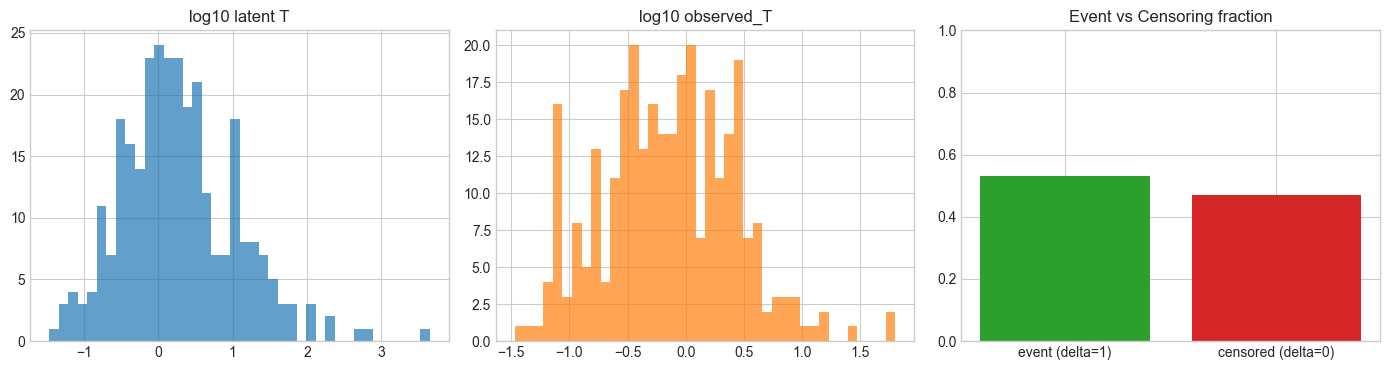

In [20]:
cfg = SimplifiedPriorConfig(
    seq_len=300,
    num_features=10,
    num_causes=10,
    generation_mode='head',
    tte_model='auto',
    censoring_mode='auto',
    seed=555,
)
out = generate_simplified_prior_data(cfg, num_datasets=1)
T = out['T'][0].numpy()
O = out['observed_T'][0].numpy()
D = out['delta'][0].numpy()

if HAS_MATPLOTLIB:
    fig, axes = plt.subplots(1, 3, figsize=(14, 3.8))
    axes[0].hist(np.log10(T), bins=40, alpha=0.7, color='#1f77b4')
    axes[0].set_title('log10 latent T')
    axes[1].hist(np.log10(O), bins=40, alpha=0.7, color='#ff7f0e')
    axes[1].set_title('log10 observed_T')
    axes[2].bar(['event (delta=1)', 'censored (delta=0)'], [float(np.mean(D)), float(1.0 - np.mean(D))], color=['#2ca02c', '#d62728'])
    axes[2].set_ylim(0, 1)
    axes[2].set_title('Event vs Censoring fraction')
    plt.tight_layout()
else:
    print('matplotlib not available; skipping plots.')

print('dataset-level rates:', {
    'event_rate': float(out['event_rate'][0].item()),
    'censoring_rate': float(out['censoring_rate'][0].item()),
})


## 10) Final Result

If all cells above ran without assertion errors, the prior generation module passed comprehensive functional tests in this notebook.
